# Technical Space Competitors
- Specifically, for Neok001 -> what patents could create blocking or design-around pressure  

But even in claims, you may see stealth and strategic drafting 
- For example, instead of using the explict naming of the target, they may use sequence identifications or structure-based claims
- To address both false negatives (strategic drafting) and false positives, independent claim text was analyzed using an AI-assisted classification pipeline
- The claims of each patent was extracted and submitted to an API-based AI model for labeling

**The model is used to detect and classify claims that involve:**
- Bispecific ADC constructs
- Antibodies targeting B7-H3
- Antibodies targeting ROR1 
- TOP1 payloads

_Under the working assumption that all records represent ADC and oncology-related inventions, due to prior CPC-based filtering performed in The Lens_

### **Scope Limitation**:
As mentioned previously in "03_direct_us_atents.ipynb", this analysis is restricted to the textual claim content
- Images (Drawings, chemical structure, etc) will not be examined
- Structure-image parsing is beyond the scope of the project

<br>

---

## Prompts for detecting same technical space

In [2]:
#Provide the developer prompt
instructions = """
You are a pharmaceutical patent analyst evaluating competitive risk to an ADC program targeting ROR1 or B7-H3 with a topoisomerase I inhibitor payload.

Core rules:
- Analyze CLAIMS first. Title and abstract are secondary.
- Base conclusions on claimed scope, not background discussion.
- Be conservative and evidence-based.
- Only assign medium/high confidence if claims clearly support it.
- Avoid over-inference from generic oncology language.

Return strict JSON only.
Keep reasoning concise but specific (3–4 sentences per section).
"""

In [ ]:
prompt = """
Analyze the following patent to determine if it poses competitive risk to an ADC program targeting:
- ROR1
- B7-H3
- A topoisomerase I inhibitor payload

TITLE:
{title}

ABSTRACT:
{abstract}

CLAIMS:
{claims}

==============================
STEP 1: Evaluate ROR1 targeting
==============================

HIGH confidence:
- Explicit mention of "ROR1", "NTRKR1", or full receptor name.
- Antibody claims specifying ROR1 binding.

MEDIUM confidence:
- Claims describing an orphan receptor tyrosine kinase with:
    • Wnt5a non-canonical signaling involvement
    • Expression in CLL or mantle cell lymphoma
    • Restricted normal adult expression
    • Binding to cysteine-rich or kringle domains
- Sequence-defined antibody clearly tied to that receptor.

LOW confidence:
- Sequence-defined antibody without clear antigen disclosure.

Do NOT flag:
- Generic tyrosine kinase
- Generic orphan receptor
- Generic B-cell antigen

==============================
STEP 2: Evaluate B7-H3 targeting
==============================

HIGH confidence:
- Explicit "B7-H3" or "CD276"
- Antibody claims specifying B7-H3 binding

MEDIUM confidence:
- Target described as 4Ig (IgV-IgC-IgV-IgC) B7 family member
- Overexpressed in neuroblastoma AND prostate AND lung/breast
- B7 family member explicitly NOT PD-L1, PD-L2, B7-H4, CTLA-4

LOW confidence:
- Sequence-defined antibody without antigen clarity

Do NOT flag:
- Generic immune checkpoint
- Generic B7 family language alone

CRITICAL DISAMBIGUATION - B7-H3 vs B7-H4:
- B7-H3 = CD276 → pro-tumorigenic, overexpressed in solid tumors, therapeutic target
- B7-H4 = VTCN1 = B7S1 → completely different protein and gene, do NOT flag as B7-H3
- If patent explicitly mentions B7-H4, VTCN1, or B7S1 → set b7h3_flag = false
- These are frequently confused — verify the exact target before flagging

==============================
STEP 3: Evaluate Topoisomerase I payload
==============================

HIGH confidence:
- Explicit DXd, SN-38, exatecan, irinotecan, topotecan, camptothecin, belotecan
- Explicit "topoisomerase I inhibitor" in payload claim

MEDIUM confidence:
- "Camptothecin derivative" or analog
- Payload described as causing DNA single-strand breaks via topo I trapping
- Structural description of camptothecin-like lactone scaffold

Do NOT flag:
- Generic DNA damage
- Generic cytotoxic payload
- Generic topoisomerase inhibitor (must specify Type I)

==============================
STEP 4: Evaluate Bispecific Constructs
==============================

bispecific_flag = true ONLY if:
- Claims describe a bispecific/multispecific antibody
AND
- One arm meets ROR1 or B7-H3 criteria above

==============================
STEP 5: Determine competitor_flag
==============================

Set competitor_flag = true ONLY if:
- ror1_flag is true with medium or high confidence
OR
- b7h3_flag is true with medium or high confidence
OR
- topo1_flag is true with medium or high confidence
OR
- bispecific_flag is true AND ROR1/B7-H3 confidence ≥ medium

If confidence is LOW only → competitor_flag = false
But note manual review in reasoning.

==============================
Return STRICT JSON:
==============================

{{
  "ror1_flag": true/false,
  "ror1_confidence": "high/medium/low/none",
  "ror1_reasoning": "",
  "b7h3_flag": true/false,
  "b7h3_confidence": "high/medium/low/none",
  "b7h3_reasoning": "",
  "topo1_flag": true/false,
  "topo1_confidence": "high/medium/low/none",
  "topo1_reasoning": "",
  "bispecific_flag": true/false,
  "bispecific_reasoning": "",
  "competitor_flag": true/false,
  "competitor_reasoning": ""
}}
"""

In [ ]:
def competitor_patent(row):
    filled_prompt = prompt.format(
        title=row['title'],
        abstract=row['abstract_text'],
        claims=row['claims_text']
    )
    
    response = client.chat.completions.create(
        model="gpt-4o", #Using 4o here for better reasoning on complex patent claims. Will be using composiiton patent subset later to reduce token usage and cost
        messages=[
            {"role": "system", "content": instructions},
            {"role": "user", "content": filled_prompt}
        ],
        response_format={"type": "json_object"},
        temperature=0
    )
    
    return json.loads(response.choices[0].message.content)

## API Validation Using a Manually Curated Patent Set

Again, ran it on ABL Bio Patent profile and noticed B7-H4 was flagged as B7-H3. So added "CRITICAL DISAMBIGUATION" paragraph to user prompt
- Results of this is in `abl_patents_competitor_4o_mini_v3.csv`

## AI-assisted flagging on 1064 Composition Patents

In [ ]:
import pandas as pd

ai_input = pd.read_csv("patents_classified_v3mini.csv") #the results with composition labeling
patents_for_ai = pd.read_csv("patents_for_ai.csv") #what was inputted, which has title, abstract and claims text

In [ ]:
composition_ids = ai_input.loc[
    ai_input["patent_type"] == "Composition",
    "lens_id"
]

In [ ]:
composition_text = patents_for_ai[
    patents_for_ai["lens_id"].isin(composition_ids)
].copy()

In [ ]:
results = []
for idx, row in composition_text.iterrows():
    print(f"Processing {idx+1}/{len(composition_text)}: {row['lens_id']}")
    try:
        result = competitor_patent(row)
        result['lens_id'] = row['lens_id']
        results.append(result)
    except Exception as e:
        print(f"  Error: {e}")
        results.append({'lens_id': row['lens_id'], 'error': str(e)})

results_df = pd.DataFrame(results)
results_df.to_csv("patents_competitor_4o.csv", index=False)
print("Done!")
results_df.head()

In [ ]:
#Couple lines ran in limit of 30K TPM for gpt-4o 
error_ids = results_df[results_df['error'].notna()]['lens_id'].tolist()
error_df = composition_text[composition_text['lens_id'].isin(error_ids)]
print(f"Errors to rerun: {len(error_df)}")

#Errors to rerun: 16

In [ ]:
#Will truncate the claims for those 16 patents, to stay within token limits
def competitor_patent(row):
    claims = str(row['claims_text'])[:6000]  # truncate here
    filled_prompt = prompt.format(
        title=row['title'],
        abstract=row['abstract_text'],
        claims=claims  # use truncated version
    )
    
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": instructions},
            {"role": "user", "content": filled_prompt}
        ],
        response_format={"type": "json_object"},
        temperature=0
    )
    
    return json.loads(response.choices[0].message.content)

In [ ]:
rerun_results = []
for idx, row in error_df.iterrows():
    print(f"Processing {row['lens_id']}")
    try:
        result = competitor_patent(row)
        result['lens_id'] = row['lens_id']
        rerun_results.append(result)
    except Exception as e:
        print(f"  Error: {e}")
        rerun_results.append({'lens_id': row['lens_id'], 'error': str(e)})
    
    
# combine with clean results
clean_df = results_df[results_df['error'].isna()]
rerun_df = pd.DataFrame(rerun_results)
final_df = pd.concat([clean_df, rerun_df], ignore_index=True)
final_df.to_csv("patents_targets_full.csv", index=False)
print(f"Total: {len(final_df)}")

After saving the `patents_targets_full.csv` in the course repo, uploaded onto this repo in `/data/ai_results/patents_targets_full.csv`
- The remaining code can now be run on this notebook

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

competitor_df = pd.read_csv("../data/ai_results/patents_targets_full.csv")

# quick summary of flags
print(competitor_df['ror1_confidence'].value_counts())
print(competitor_df['b7h3_confidence'].value_counts())
print(competitor_df['topo1_confidence'].value_counts())
print(f"\nTotal competitors: {competitor_df['competitor_flag'].sum()}")

ror1_confidence
none      1029
high        27
medium       1
Name: count, dtype: int64
b7h3_confidence
none      997
high       58
medium      2
Name: count, dtype: int64
topo1_confidence
none      910
high      111
medium     23
low        13
Name: count, dtype: int64

Total competitors: 187


In [47]:
print(f"ROR1 high/medium: {competitor_df['ror1_confidence'].isin(['high','medium']).sum()}")   # 28
print(f"B7-H3 high/medium: {competitor_df['b7h3_confidence'].isin(['high','medium']).sum()}")  # 60
print(f"Topo1 high/medium: {competitor_df['topo1_confidence'].isin(['high','medium']).sum()}") # 134

# unique patents hitting at least one
competitor_ids = set(
    competitor_df[competitor_df['ror1_confidence'].isin(['high','medium'])]['lens_id'].tolist() +
    competitor_df[competitor_df['b7h3_confidence'].isin(['high','medium'])]['lens_id'].tolist() +
    competitor_df[competitor_df['topo1_confidence'].isin(['high','medium'])]['lens_id'].tolist()
)
print(f"Unique competitor patents: {len(competitor_ids)}")

ROR1 high/medium: 28
B7-H3 high/medium: 60
Topo1 high/medium: 134
Unique competitor patents: 188


In [48]:
# see how many hit multiple targets (as total competitors is 187 but total high is higher)
competitor_df['targets_hit'] = (
    competitor_df['ror1_confidence'].isin(['high', 'medium']).astype(int) +
    competitor_df['b7h3_confidence'].isin(['high', 'medium']).astype(int) +
    competitor_df['topo1_confidence'].isin(['high', 'medium']).astype(int)
)

print(competitor_df['targets_hit'].value_counts().sort_index())

targets_hit
0    869
1    158
2     26
3      4
Name: count, dtype: int64


In [49]:
# patents where model said not competitor but we'd flag them
competitor_df[
    (competitor_df['competitor_flag'] == False) & 
    (competitor_df['targets_hit'] >= 1)
][['lens_id', 'ror1_confidence', 'b7h3_confidence', 'topo1_confidence', 'competitor_flag', 'competitor_reasoning']]

,lens_id,ror1_confidence,b7h3_confidence,topo1_confidence,competitor_flag,competitor_reasoning
244,179-698-917-483-710,medium,none,none,False,While ROR1 is mentioned as a potential kinase ...


In [10]:
#Set the one above as competitor flag, as it meets the criteria of hitting at least one target with medium or high confidence
competitor_df['competitor_flag'] = competitor_df['lens_id'].isin(competitor_ids)
print(f"Total competitors: {competitor_df['competitor_flag'].sum()}")  # 188

Total competitors: 188


In [11]:
#combine it with our full patent dataset to see details on the competitors
import pandas as pd

# classification results if needed
classified_df = pd.read_csv("../data/ai_results/patents_classified_v3mini.csv")

In [12]:
#Initial file jsonl with all info on US jurisdiction
df_raw = pd.read_json("../data/raw/US-enforced-patents.jsonl", lines=True)
print(df_raw.shape)
print(df_raw.columns.tolist())

(2331, 16)
['lens_id', 'jurisdiction', 'doc_number', 'kind', 'date_published', 'doc_key', 'docdb_id', 'lang', 'biblio', 'families', 'sequence_listing', 'legal_status', 'abstract', 'claims', 'description', 'publication_type']


In [38]:
df_full = competitor_df.merge(df_raw[['lens_id', 'biblio']], on='lens_id', how='left')
print(df_full.shape)  # should be 1057

# extract all owners
def extract_all_owners(biblio):
    try:
        owners = biblio['parties']['owners_all']
        return [o['extracted_name']['value'] for o in owners]
    except:
        try:
            applicants = biblio['parties']['applicants']
            return [a['extracted_name']['value'] for a in applicants]
        except:
            return []

df_full['owners'] = df_full['biblio'].apply(extract_all_owners)

# explode so each owner gets its own row
df_exploded = df_full.explode('owners')

# competitor patents per owner
competitor_owners = df_exploded[df_exploded['competitor_flag'] == True]
competitor_owners['owners'].value_counts().head(40)

(1057, 17)


owners
DAIICHI SANKYO COMPANY LIMITED                                                                          11
SHANGHAI HENGRUI PHARMACEUTICAL CO. LTD                                                                  7
JIANGSU HENGRUI MEDICINE CO. LTD                                                                         6
NOVARTIS AG                                                                                              4
SYSTIMMUNE INC                                                                                           4
BIO-THERA SOLUTIONS LTD                                                                                  4
BAILI-BIO (CHENGDU) PHARMACEUTICAL CO. LTD                                                               4
JIANGSU HANSOH PHARMACEUTICAL GROUP CO. LTD                                                              3
ZYMEWORKS BC INC                                                                                         3
NOVARTIS INSTITUTES FOR BIOMED

In [39]:
counts = competitor_owners['owners'].value_counts()
print(f"Total rows in value_counts: {counts.sum()}")
print(f"Unique owners: {len(counts)}")
print(f"Competitor patents (before explode): {competitor_df['competitor_flag'].sum()}")

Total rows in value_counts: 272
Unique owners: 206
Competitor patents (before explode): 188


188 unique competitor patents
272 total owner-patent relationships (so ~84 patents had multiple owners)
206 unique owners

In [40]:
comp_targets = df_exploded[df_exploded['competitor_flag'] == True][['owners', 'lens_id']].merge(
    competitor_df[['lens_id', 'ror1_confidence', 'b7h3_confidence', 'topo1_confidence', 'bispecific_flag']], 
    on='lens_id', how='left'
)

# create binary columns for each target hit
comp_targets['ROR1'] = comp_targets['ror1_confidence'].isin(['high', 'medium']).astype(int)
comp_targets['B7H3'] = comp_targets['b7h3_confidence'].isin(['high', 'medium']).astype(int)
comp_targets['Topo1'] = comp_targets['topo1_confidence'].isin(['high', 'medium']).astype(int)
comp_targets['Bispecific'] = comp_targets['bispecific_flag'].astype(int)

# group by owner
owner_targets = comp_targets.groupby('owners')[['ROR1', 'B7H3', 'Topo1', 'Bispecific']].sum()
owner_targets['Total'] = owner_targets.sum(axis=1)
owner_targets = owner_targets.sort_values('Total', ascending=False)

print(owner_targets.shape)
owner_targets.head(20)

(206, 5)


,ROR1,B7H3,Topo1,Bispecific,Total
owners,,,,,
DAIICHI SANKYO COMPANY LIMITED,0,7,4,0,11
SHANGHAI HENGRUI PHARMACEUTICAL CO. LTD,0,4,5,0,9
JIANGSU HENGRUI MEDICINE CO. LTD,0,3,5,0,8
BIO-THERA SOLUTIONS LTD,1,2,4,0,7
NOVARTIS AG,2,3,1,0,6
NOVARTIS INSTITUTES FOR BIOMEDICAL RESEARCH INC,2,3,0,0,5
SYSTIMMUNE INC,0,1,4,0,5
BAILI-BIO (CHENGDU) PHARMACEUTICAL CO. LTD,0,1,4,0,5
JIANGSU HANSOH PHARMACEUTICAL GROUP CO. LTD,0,1,3,0,4


In [ ]:
#Technical space competitors with target breakdown (in US jurisdiction only, based on patents classified as composition by gtp-4o mini and analyzed by gtp-4o for target/payload/bispecific relevance)
owner_targets.to_csv('../data/processed/technical_space_competitors_206.csv')

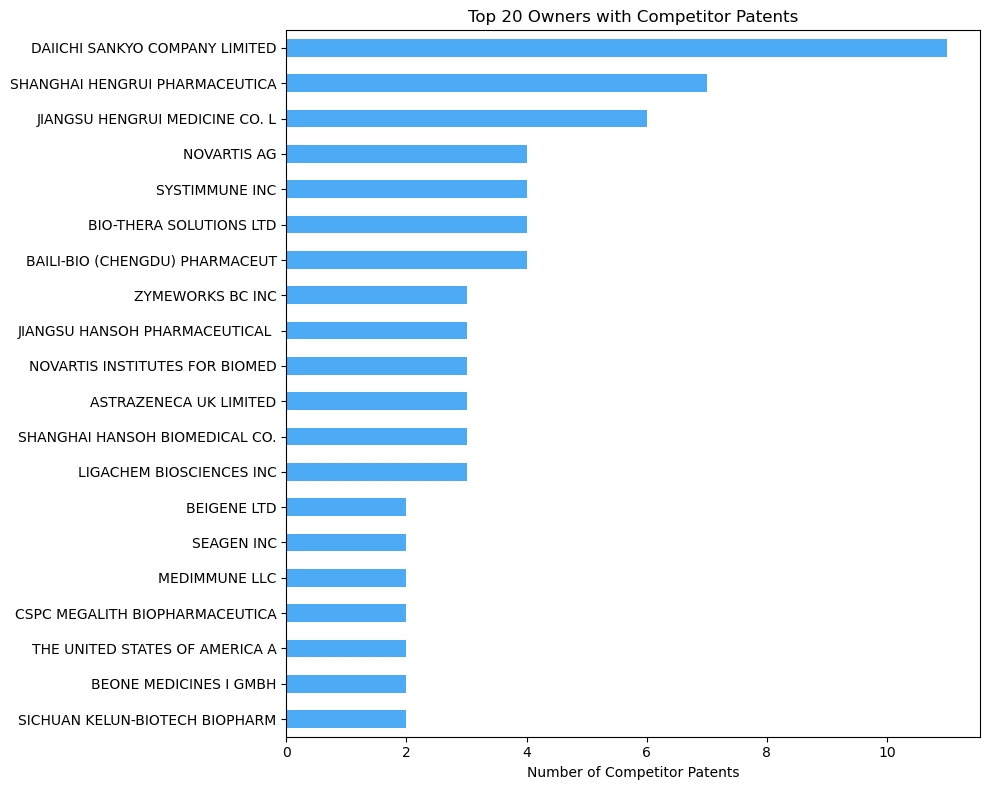

In [44]:
fig, ax = plt.subplots(figsize=(10, 8))

top20 = counts.head(20).sort_values()
top20.index = [name[:30] for name in top20.index]  # truncate to 30 chars

top20.plot(kind='barh', ax=ax, color='#2196F3', alpha=0.8)
ax.set_title('Top 20 Owners with Competitor Patents')
ax.set_xlabel('Number of Competitor Patents')
ax.set_ylabel('')
plt.tight_layout()
#to save: plt.savefig("competitor_owners.png", dpi=150)
plt.show()

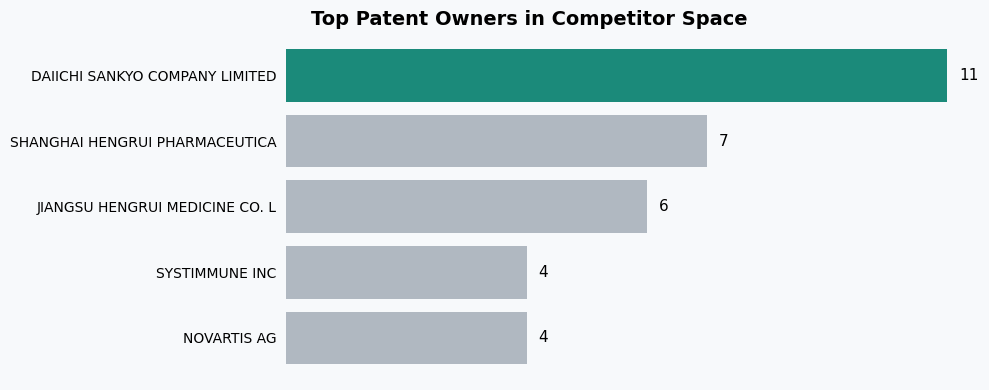

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

# Sort so largest is at top
top5 = counts.head(5).sort_values()
top5.index = [name[:30] for name in top5.index]

# Colors: highlight largest
colors = ['#B0B8C1'] * len(top5)
colors[-1] = '#1B8A7A'  # teal highlight for largest

bars = ax.barh(top5.index, top5.values, color=colors)

# Remove spines for clean look
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

# Remove x ticks
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')

# Add value labels at end of bars
for i, v in enumerate(top5.values):
    ax.text(v + 0.2, i, str(v), va='center', fontsize=11)

ax.set_title(
    'Top Patent Owners in Competitor Space',
    fontsize=14,
    weight='bold',
    x=0.35,   # shift title more
    y = 1
)

ax.set_xticks([])          # remove x-axis numbers
ax.set_xlabel('')          # remove x-axis label
ax.set_ylabel('')
ax.spines['bottom'].set_visible(False)

ax.set_facecolor('#F7F9FB')
fig.patch.set_facecolor('#F7F9FB')

plt.tight_layout()
plt.show()

In [54]:
# check if ABL Bio appears anywhere in the full dataset
df_exploded[df_exploded['owners'].str.contains('ABL', na=False)]['owners'].value_counts()

owners
ABL BIO INC    2
ABLYNX N.V     1
Name: count, dtype: int64

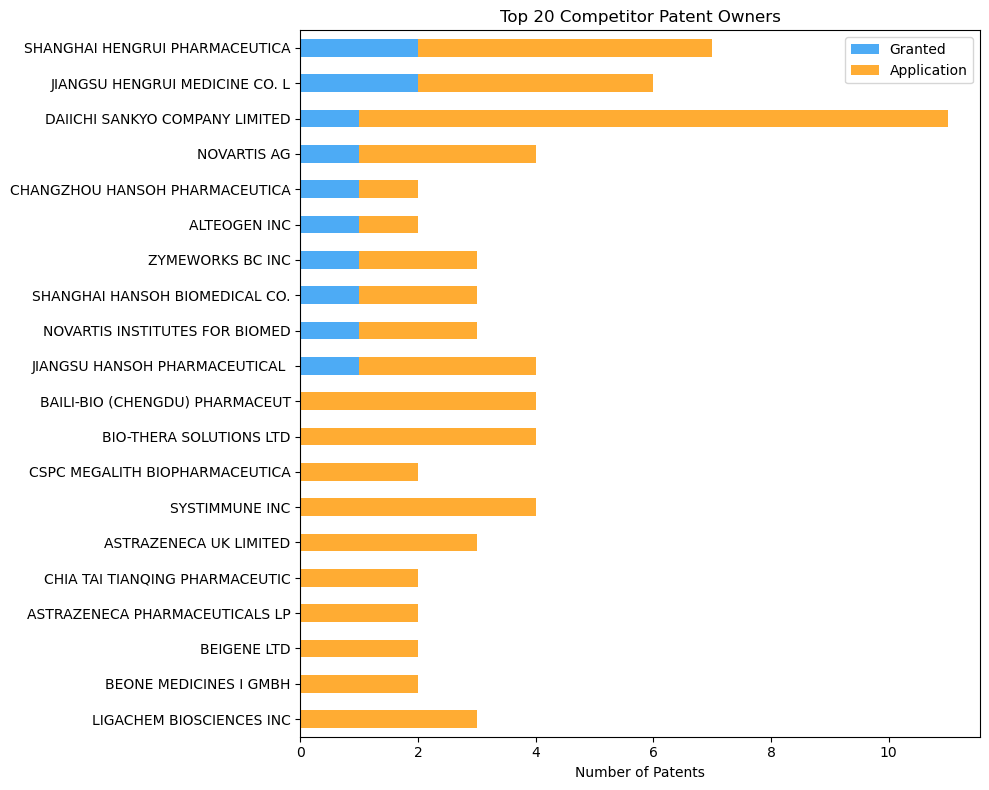

In [59]:
df_exploded2 = df_full.copy()
df_exploded2 = df_exploded2.merge(df_raw[['lens_id', 'publication_type']], on='lens_id', how='left')
df_exploded2 = df_exploded2.explode('owners')
df_exploded2['owners_short'] = df_exploded2['owners'].str[:30]

# filter competitors only
comp = df_exploded2[df_exploded2['competitor_flag'] == True]

# pivot for stacked bar
pivot = comp.groupby(['owners_short', 'publication_type']).size().unstack(fill_value=0)

# get top 20 by total
pivot['total'] = pivot.sum(axis=1)
pivot = pivot.nlargest(20, 'total').drop(columns='total').sort_values(pivot.columns[0])

# plot
fig, ax = plt.subplots(figsize=(10, 8))
pivot.plot(kind='barh', stacked=True, ax=ax, 
           color={'GRANTED_PATENT': '#2196F3', 'PATENT_APPLICATION': '#FF9800'}, 
           alpha=0.8)
ax.set_title('Top 20 Competitor Patent Owners')
ax.set_xlabel('Number of Patents')
ax.set_ylabel('')
ax.legend(['Granted', 'Application'])
plt.tight_layout()
#to save: plt.savefig("competitor_owners_status.png", dpi=150)
plt.show()

/var/folders/ps/9mfd94h1197dqk96m56rhv040000gn/T/ipykernel_38665/1797350122.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


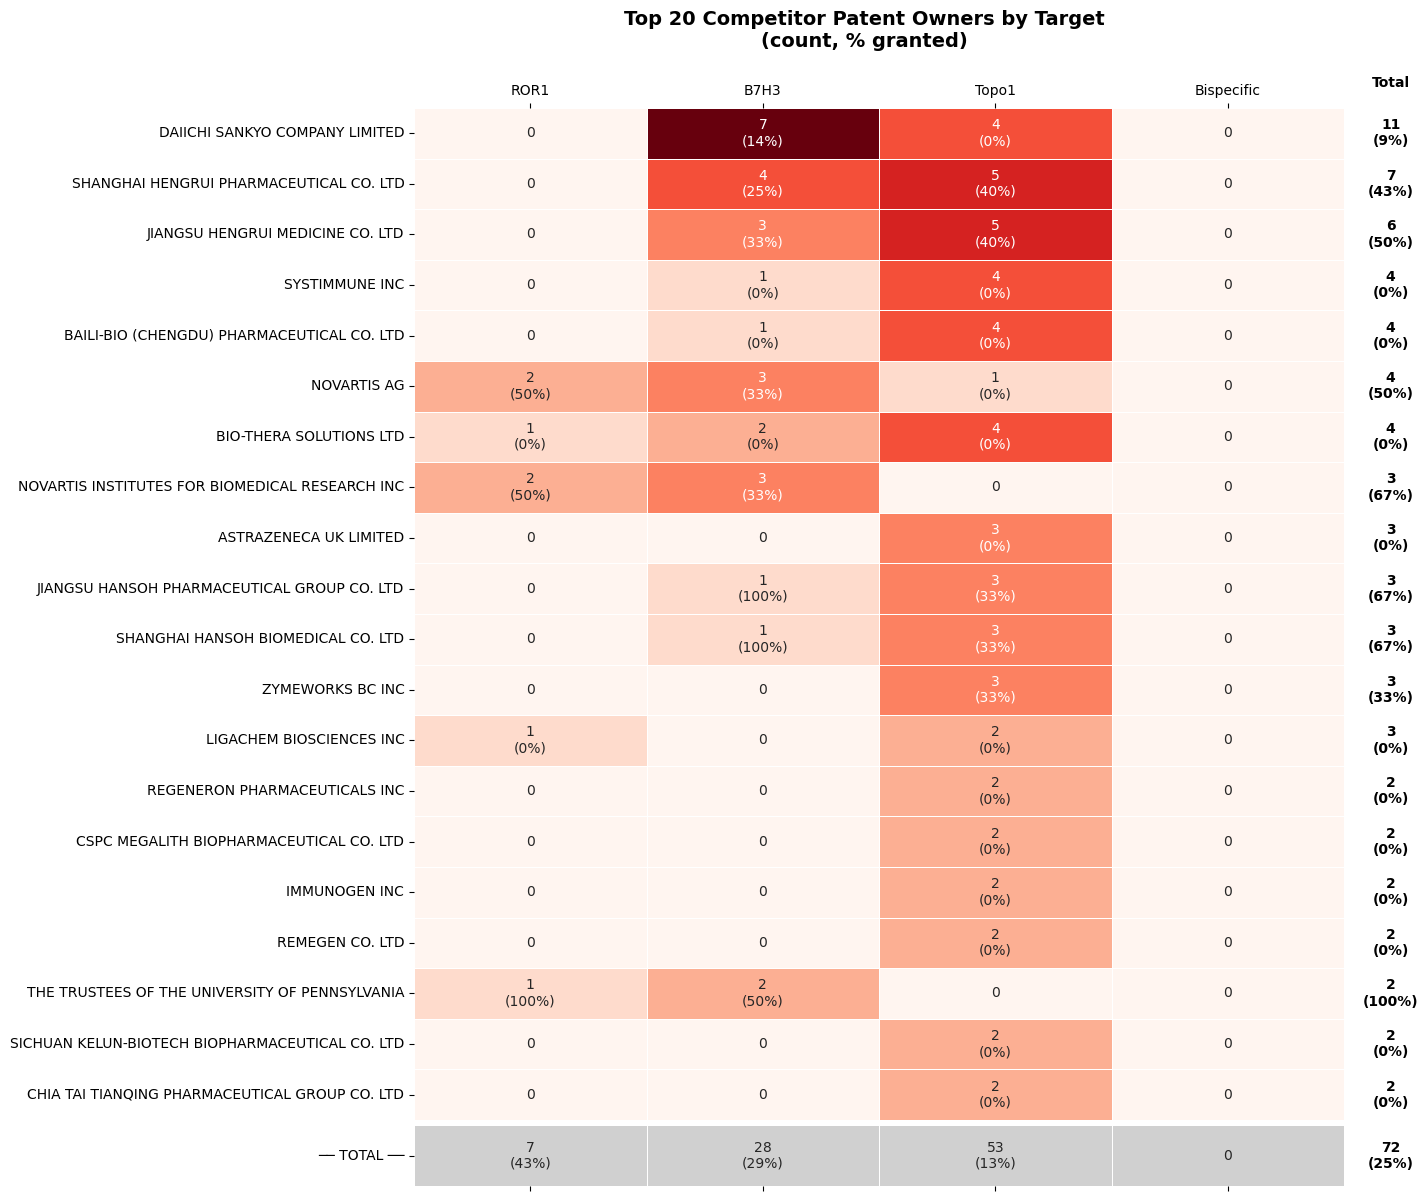

In [68]:
def make_annot(row, col):
    n = int(row[col])
    if f'{col}_g' not in row.index:
        g = int(row['ROR1_g']) + int(row['B7H3_g']) + int(row['Topo1_g'])
        pct = round(g / n * 100) if n > 0 else 0
        return f"{n}\n({pct}%)" if n > 0 else '0'
    g = int(row[f'{col}_g'])
    if n == 0:
        return '0'
    pct = round(g / n * 100)
    return f"{n}\n({pct}%)"

def make_annot_total(row):
    n = int(row['Total'])
    g = int(row['ROR1_g']) + int(row['B7H3_g']) + int(row['Topo1_g'])
    pct = round(g / n * 100) if n > 0 else 0
    return f"{n}\n({pct}%)" if n > 0 else '0'

# use top 20
owner_annot = comp_targets2.groupby('owners').agg(
    ROR1=('ROR1','sum'), ROR1_g=('ROR1_granted','sum'),
    B7H3=('B7H3','sum'), B7H3_g=('B7H3_granted','sum'),
    Topo1=('Topo1','sum'), Topo1_g=('Topo1_granted','sum'),
    Bispecific=('Bispecific','sum'),
    Total=('lens_id','nunique')
).sort_values('Total', ascending=False).head(20)

# summary row
summary = pd.DataFrame({
    'ROR1': [owner_annot['ROR1'].sum()], 'ROR1_g': [owner_annot['ROR1_g'].sum()],
    'B7H3': [owner_annot['B7H3'].sum()], 'B7H3_g': [owner_annot['B7H3_g'].sum()],
    'Topo1': [owner_annot['Topo1'].sum()], 'Topo1_g': [owner_annot['Topo1_g'].sum()],
    'Bispecific': [owner_annot['Bispecific'].sum()],
    'Total': [owner_annot['Total'].sum()],
}, index=['── TOTAL ──'])

owner_annot = pd.concat([owner_annot, summary])

# heatmap values — exclude Total from color scaling
heat_cols = ['ROR1', 'B7H3', 'Topo1', 'Bispecific']
heat_vals = owner_annot[heat_cols].copy().astype(float)

# Total as separate annotation only (not colored)
annot = owner_annot.apply(lambda row: pd.Series({
    'ROR1': make_annot(row, 'ROR1'),
    'B7H3': make_annot(row, 'B7H3'),
    'Topo1': make_annot(row, 'Topo1'),
    'Bispecific': str(int(row['Bispecific'])) if int(row['Bispecific']) > 0 else '0',
    'Total': make_annot_total(row),
}), axis=1)

# add Total as a plain text column (white background)
heat_vals['Total'] = 0  # dummy value so it renders but stays white

heat_main = heat_vals.iloc[:-1]
heat_summary = heat_vals.iloc[[-1]]

fig, axes = plt.subplots(2, 1, figsize=(12, 14),
                          gridspec_kw={'height_ratios': [25, 1.5], 'hspace': 0.01})

# only color ROR1, B7H3, Topo1, Bispecific — no Total in heatmap at all
heat_cols = ['ROR1', 'B7H3', 'Topo1', 'Bispecific']
heat_main = owner_annot[heat_cols].iloc[:-1].astype(float)
heat_summary = owner_annot[heat_cols].iloc[[-1]].astype(float)

annot_main = annot[heat_cols].iloc[:-1]
annot_summary = annot[heat_cols].iloc[[-1]]

sns.heatmap(heat_main, annot=annot_main, fmt='', ax=axes[0],
            cmap='Reds', linewidths=0.5, linecolor='white', cbar=False, vmin=0)
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].tick_params(axis='x', rotation=0, top=True, labeltop=True, bottom=False, labelbottom=False)
axes[0].tick_params(axis='y', rotation=0)

# add Total as clean text column on the right
for i, (idx, row) in enumerate(annot.iloc[:-1].iterrows()):
    axes[0].text(4.2, i + 0.5, row['Total'], ha='center', va='center',
                 fontsize=10, zorder=3, fontweight='bold')
axes[0].text(4.2, -0.5, 'Total', ha='center', va='center', fontsize=10, fontweight='bold')

sns.heatmap(heat_summary, annot=annot_summary, fmt='', ax=axes[1],
            cmap=plt.cm.colors.ListedColormap(['#D0D0D0']),
            linewidths=0.5, linecolor='white', cbar=False, vmin=0, vmax=1)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0, labelbottom=False)
axes[1].tick_params(axis='y', rotation=0)
axes[1].text(4.2, 0.5, annot.iloc[-1]['Total'], ha='center', va='center',
             fontsize=10, fontweight='bold')

fig.suptitle('Top 20 Competitor Patent Owners by Target\n(count, % granted)',
             fontsize=14, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

In [70]:
# inspect one biblio record to find date fields
import json

sample = df_full['biblio'].dropna().iloc[0]
if isinstance(sample, str):
    sample = ast.literal_eval(sample)

# print all top level keys
print(sample.keys())

# look for anything date-related
for key, val in sample.items():
    if 'date' in key.lower() or 'priority' in key.lower() or 'filing' in key.lower():
        print(f"\n{key}:", val)

dict_keys(['publication_reference', 'application_reference', 'application_number', 'priority_claims', 'invention_title', 'parties', 'classifications_ipcr', 'classifications_cpc', 'references_cited', 'cited_by'])

priority_claims: {'claims': [{'jurisdiction': 'US', 'doc_number': '201614992714', 'kind': 'A', 'date': '2016-01-11', 'sequence': 1}, {'jurisdiction': 'US', 'doc_number': '201514859242', 'kind': 'A', 'date': '2015-09-18', 'sequence': 2}, {'jurisdiction': 'US', 'doc_number': '201514807789', 'kind': 'A', 'date': '2015-07-23', 'sequence': 3}, {'jurisdiction': 'US', 'doc_number': '201414466951', 'kind': 'A', 'date': '2014-08-22', 'sequence': 4}, {'jurisdiction': 'US', 'doc_number': '201414466842', 'kind': 'A', 'date': '2014-08-22', 'sequence': 5}, {'jurisdiction': 'US', 'doc_number': '2013027391', 'kind': 'W', 'date': '2013-02-22', 'sequence': 6}, {'jurisdiction': 'US', 'doc_number': '201261719803', 'kind': 'P', 'date': '2012-10-29', 'sequence': 7}, {'jurisdiction': 'US', 'doc_numb

In [71]:
#The earliest priority date is in priority_claims.earliest_claim.date. Using that to look at expiry horizon (estimating 20 years from priority date for standard patents, with caveats around extensions, PTE, etc.)
def extract_priority_date(biblio):
    try:
        if isinstance(biblio, str):
            biblio = ast.literal_eval(biblio)
        return biblio['priority_claims']['earliest_claim']['date']
    except:
        return None

df_full['priority_date'] = df_full['biblio'].apply(extract_priority_date)
df_full['priority_date'] = pd.to_datetime(df_full['priority_date'], errors='coerce')
df_full['expiry_date'] = df_full['priority_date'] + pd.DateOffset(years=20)
df_full['years_to_expiry'] = (df_full['expiry_date'] - pd.Timestamp.now()).dt.days / 365

print(df_full[['lens_id', 'priority_date', 'expiry_date', 'years_to_expiry']].head(10))
print(f"\nAlready expired: {(df_full['years_to_expiry'] < 0).sum()}")
print(f"Expiring within 5 years: {((df_full['years_to_expiry'] >= 0) & (df_full['years_to_expiry'] <= 5)).sum()}")
print(f"Expiring 5-10 years: {((df_full['years_to_expiry'] > 5) & (df_full['years_to_expiry'] <= 10)).sum()}")
print(f"Expiring 10+ years: {(df_full['years_to_expiry'] > 10).sum()}")

               lens_id priority_date expiry_date  years_to_expiry
0  039-300-232-515-637    2012-02-24  2032-02-24         5.980822
1  094-825-731-979-424    2016-02-04  2036-02-04         9.928767
2  064-424-066-709-583    2016-08-09  2036-08-09        10.441096
3  186-558-921-944-814    2013-12-25  2033-12-25         7.816438
4  075-145-950-118-300    2013-01-15  2033-01-15         6.873973
5  079-324-326-110-937    2012-12-21  2032-12-21         6.805479
6  106-587-702-968-526    2019-07-22  2039-07-22        13.391781
7  107-703-317-876-109    2011-04-15  2031-04-15         5.117808
8  152-059-136-452-443    2016-07-19  2036-07-19        10.383562
9  011-388-852-098-320    2015-05-22  2035-05-22         9.221918

Already expired: 14
Expiring within 5 years: 55
Expiring 5-10 years: 208
Expiring 10+ years: 780


This is expiry horizon for df_full (all 1057 patents)

In [ ]:
#to filter to competitors (those flagged as competitor in same technical space) only and see their expiry horizon
comp_expiry = df_full[df_full['competitor_flag'] == True].copy()

print(f"Already expired: {(comp_expiry['years_to_expiry'] < 0).sum()}")
print(f"Expiring within 5 years: {((comp_expiry['years_to_expiry'] >= 0) & (comp_expiry['years_to_expiry'] <= 5)).sum()}")
print(f"Expiring 5-10 years: {((comp_expiry['years_to_expiry'] > 5) & (comp_expiry['years_to_expiry'] <= 10)).sum()}")
print(f"Expiring 10+ years: {(comp_expiry['years_to_expiry'] > 10).sum()}")

Already expired: 1
Expiring within 5 years: 4
Expiring 5-10 years: 15
Expiring 10+ years: 168


In [ ]:
# What competitor expiry data looks like
comp_expiry['expiry_year'] = comp_expiry['expiry_date'].dt.year
comp_expiry['target'] = comp_expiry.apply(lambda r: 
    'ROR1' if r['ror1_confidence'] in ['high','medium'] else
    'B7H3' if r['b7h3_confidence'] in ['high','medium'] else
    'Topo1' if r['topo1_confidence'] in ['high','medium'] else 'Other', axis=1)

comp_expiry['expiry_year'].value_counts().sort_index()

expiry_year
2026     1
2027     1
2028     1
2030     1
2031     4
2032     1
2033     2
2034     3
2035     5
2036    14
2037     9
2038    18
2039    21
2040    37
2041    32
2042    33
2043     5
Name: count, dtype: int64

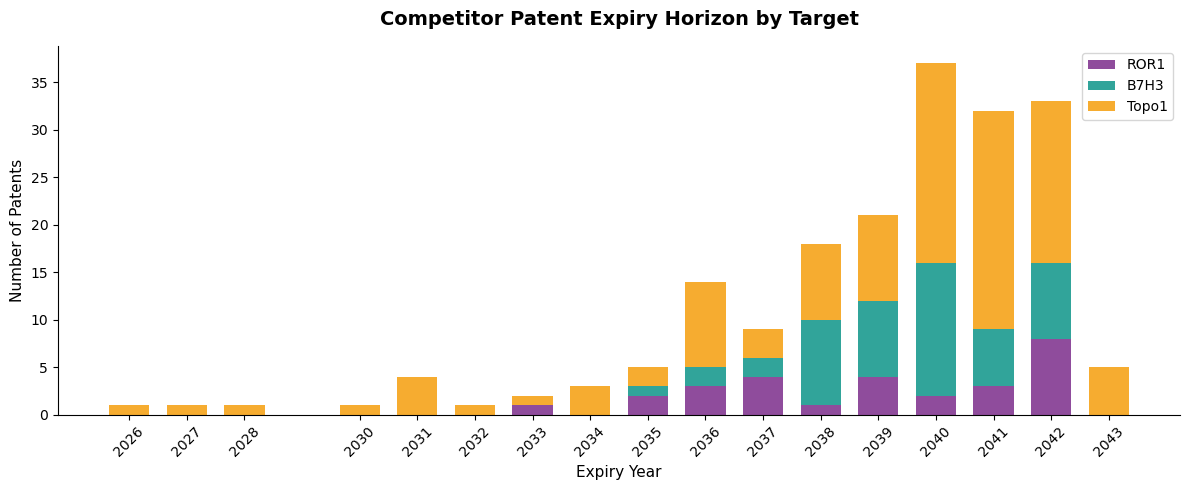

In [77]:
comp_expiry2 = comp_expiry.copy()

comp_expiry2['target'] = comp_expiry2.apply(lambda r:
    'ROR1' if r['ror1_confidence'] in ['high','medium'] else
    'B7H3' if r['b7h3_confidence'] in ['high','medium'] else
    'Topo1' if r['topo1_confidence'] in ['high','medium'] else 'Other', axis=1)

# group by year and target
expiry_pivot = comp_expiry2.groupby(['expiry_year', 'target']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))

colors = {'ROR1': '#7B2D8B', 'B7H3': '#0D9488', 'Topo1': '#F59E0B', 'Other': '#CBD5E1'}
bottom = None
for target in ['ROR1', 'B7H3', 'Topo1', 'Other']:
    if target in expiry_pivot.columns:
        vals = expiry_pivot.get(target, 0)
        ax.bar(expiry_pivot.index, vals, bottom=bottom,
               label=target, color=colors[target], alpha=0.85, width=0.7)
        bottom = vals if bottom is None else bottom + vals

ax.set_title('Competitor Patent Expiry Horizon by Target', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Expiry Year', fontsize=11)
ax.set_ylabel('Number of Patents', fontsize=11)
ax.set_xticks(expiry_pivot.index)
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [78]:
# target combination overlap
comp_combos = competitor_df[competitor_df['competitor_flag'] == True].copy()

comp_combos['ROR1'] = comp_combos['ror1_confidence'].isin(['high','medium'])
comp_combos['B7H3'] = comp_combos['b7h3_confidence'].isin(['high','medium'])
comp_combos['Topo1'] = comp_combos['topo1_confidence'].isin(['high','medium'])
comp_combos['Bispecific'] = comp_combos['bispecific_flag'].astype(bool)

# label each patent by its combination
def get_combo(row):
    targets = []
    if row['ROR1']: targets.append('ROR1')
    if row['B7H3']: targets.append('B7H3')
    if row['Topo1']: targets.append('Topo1')
    if row['Bispecific']: targets.append('Bispecific')
    if len(targets) == 0: return 'Other'
    return ' + '.join(targets)

comp_combos['combo'] = comp_combos.apply(get_combo, axis=1)
combo_counts = comp_combos['combo'].value_counts()
print(combo_counts)

combo
Topo1                        110
B7H3                          34
B7H3 + Topo1                  14
ROR1                          11
ROR1 + Topo1                   5
ROR1 + B7H3                    5
ROR1 + B7H3 + Topo1            4
ROR1 + Bispecific              1
B7H3 + Topo1 + Bispecific      1
B7H3 + Bispecific              1
ROR1 + B7H3 + Bispecific       1
Name: count, dtype: int64


/var/folders/ps/9mfd94h1197dqk96m56rhv040000gn/T/ipykernel_38665/3795269735.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


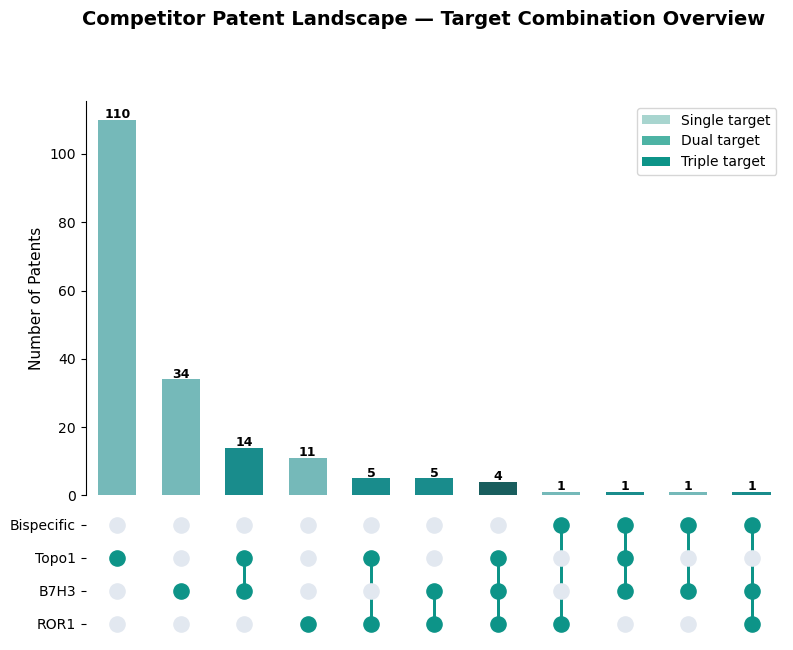

In [92]:
fig, (ax_bar, ax_matrix) = plt.subplots(2, 1, figsize=(9, 7),
                                          gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

combos = combo_counts.index.tolist()
counts = combo_counts.values.tolist()
targets = ['ROR1', 'B7H3', 'Topo1', 'Bispecific']

# color bars by single vs multi target
def get_color(combo):
    n_targets = len([t for t in ['ROR1', 'B7H3', 'Topo1'] if t in combo])
    if n_targets == 1:
        return "#66b2b2"  # light teal
    elif n_targets == 2:
        return "#008080"  # medium teal
    else:
        return "#004c4c"  # dark teal

colors = [get_color(c) for c in combos]

# top: bar chart
ax_bar.bar(range(len(combos)), counts, color=colors, alpha=0.9, width=0.6)
for i, v in enumerate(counts):
    ax_bar.text(i, v + 0.5, str(v), ha='center', fontsize=9, fontweight='bold')
ax_bar.set_ylabel('Number of Patents', fontsize=11)
ax_bar.set_xticks([])
ax_bar.spines[['top', 'right', 'bottom']].set_visible(False)
ax_bar.set_xlim(-0.5, len(combos) - 0.5)

# bottom: dot matrix showing which targets are in each combo
for col_i, combo in enumerate(combos):
    active = [t for t in targets if t in combo]
    for row_i, target in enumerate(targets):
        if target in active:
            ax_matrix.scatter(col_i, row_i, s=120, color='#0D9488', zorder=5)
            # draw connecting line if multiple targets
            if len(active) > 1:
                first = targets.index(active[0])
                last = targets.index(active[-1])
                ax_matrix.plot([col_i, col_i], [first, last],
                               color='#0D9488', linewidth=2, zorder=4)
        else:
            ax_matrix.scatter(col_i, row_i, s=120, color='#E2E8F0', zorder=5)

ax_matrix.set_yticks(range(len(targets)))
ax_matrix.set_yticklabels(targets, fontsize=10)
ax_matrix.set_xticks([])
ax_matrix.set_xlim(-0.5, len(combos) - 0.5)
ax_matrix.set_ylim(-0.5, len(targets) - 0.5)
ax_matrix.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#A8D5CF', label='Single target'),
    Patch(facecolor='#4DB3A4', label='Dual target'),
    Patch(facecolor='#0D9488', label='Triple target')
]
ax_bar.legend(handles=legend_elements, loc='upper right')

fig.suptitle('Competitor Patent Landscape — Target Combination Overview',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()